# Situation Problem 1: Algorithmic Analysis of Biological Sequences
## Parte 1 — Understanding the Data

**Materia:** TC2038 – Advanced Algorithms Design

### Objetivo

Las secuencias biológicas pueden representarse como cadenas de caracteres y, por lo
tanto, analizarse con algoritmos clásicos de procesamiento de texto. La pregunta que
guía toda la actividad es:

> *How can different algorithmic strategies be used to efficiently analyze, search,
> compare, or characterize biological sequences?*

En esta **Parte 1** el objetivo es más acotado: **entender los datos antes de
analizarlos**. Para cada archivo se debe leer la secuencia, normalizar su formato y
caracterizarla reportando su longitud, su alfabeto, las frecuencias absolutas y
relativas de cada símbolo, los símbolos más y menos frecuentes, y cualquier carácter
inesperado.

### Archivos analizados

| # | Archivo | Accession |
|---|---------|-----------|
| 1 | `SARS-COV-2-MT106054.1.txt` | MT106054.1 |
| 2 | `SARS-COV-2-MN908947.3.txt` | MN908947.3 |

Ambos corresponden a genomas de *SARS-CoV-2*.

### Alcance

Esta entrega implementa **únicamente la Parte 1**. No se incluyen alineamientos,
búsqueda de patrones, detección de mutaciones ni ningún otro análisis avanzado; esos
temas corresponden a partes posteriores de la situación problema.

**Definiciones que se usan a lo largo del notebook**

- **Longitud total (n):** número de símbolos de la secuencia *después* de retirar
  únicamente elementos de formato (encabezados FASTA, saltos de línea, líneas vacías
  y espacios en blanco).
- **Frecuencia absoluta:** número de veces que aparece un símbolo en la secuencia.
- **Frecuencia relativa:** frecuencia absoluta dividida entre la longitud total.
- **Porcentaje:** frecuencia relativa multiplicada por 100.
- **Alfabeto esperado:** `{A, C, G, T}`. Cualquier otro símbolo se reporta por
  separado, pero **no se elimina ni se transforma**.

---
## B. Importaciones y configuración

Se usan dependencias mínimas:

- **Biblioteca estándar de Python** (`pathlib`, `collections`) para leer archivos y
  para las comprobaciones.
- **pandas** únicamente para presentar tablas.
- **matplotlib** únicamente para las gráficas de barras.

> El conteo de símbolos **no** se delega a ninguna librería: se implementa a mano en
> la sección D. pandas y matplotlib solo sirven para mostrar resultados.

### Cómo se resuelven las rutas

Para evitar rutas absolutas ligadas a una computadora en particular, las rutas se
construyen de forma **relativa al directorio de trabajo del kernel**
(`Path.cwd()`, que normalmente es la carpeta donde está guardado el notebook).
Se buscan los archivos en una lista corta de carpetas candidatas:
la carpeta actual, `./dataset/`, la carpeta padre y `../dataset/`.

Si quieres usar otra ubicación, basta con editar `CARPETAS_CANDIDATAS` o
`NOMBRES_ARCHIVOS` en la celda siguiente: **son el único lugar donde se configuran
las rutas**.

*(Este notebook no instala paquetes. Requiere `pandas` y `matplotlib` ya instalados
en el entorno del kernel.)*

In [11]:
from pathlib import Path
from collections import Counter          # solo para las comprobaciones finales

import pandas as pd
import matplotlib.pyplot as plt

# --- ÚNICA CELDA DE CONFIGURACIÓN DE RUTAS ---------------------------------

# Nombres de los archivos a analizar (en el orden en que se reportarán).
NOMBRES_ARCHIVOS = [
    "SARS-COV-2-MT106054.1.txt",
    "SARS-COV-2-MN908947.3.txt",
]

# Carpetas donde se buscarán esos nombres, relativas al directorio de trabajo.
DIRECTORIO_ACTUAL = Path.cwd()
CARPETAS_CANDIDATAS = [
    DIRECTORIO_ACTUAL,
    DIRECTORIO_ACTUAL / "dataset",
    DIRECTORIO_ACTUAL.parent,
    DIRECTORIO_ACTUAL.parent / "dataset",
]

# Alfabeto esperado para esta actividad.
ALFABETO_ESPERADO = ("A", "C", "G", "T")

# Colores fijos por símbolo, para que las mismas bases se vean igual en ambas gráficas.
COLORES = {"A": "#2e7d32", "C": "#1565c0", "G": "#ef6c00", "T": "#c62828"}
COLOR_OTROS = "#757575"


def resolver_ruta(nombre_archivo):
    """Devuelve la primera ruta existente para `nombre_archivo`, o None si no aparece."""
    for carpeta in CARPETAS_CANDIDATAS:
        candidata = carpeta / nombre_archivo
        if candidata.is_file():
            return candidata
    return None


RUTAS = {nombre: resolver_ruta(nombre) for nombre in NOMBRES_ARCHIVOS}

print("Directorio de trabajo:", DIRECTORIO_ACTUAL)
print()
faltantes = []
for nombre, ruta in RUTAS.items():
    if ruta is None:
        faltantes.append(nombre)
        print(f"  [NO ENCONTRADO] {nombre}")
    else:
        print(f"  [OK] {nombre}  ->  {ruta}")

if faltantes:
    print()
    print("Faltan archivos. Colócalos en alguna de estas carpetas:")
    for carpeta in CARPETAS_CANDIDATAS:
        print("   -", carpeta)
    print("...o edita NOMBRES_ARCHIVOS / CARPETAS_CANDIDATAS en esta misma celda.")
    print("Mientras falten, el análisis NO se ejecuta con datos reales.")

Directorio de trabajo: /home/gugora/algorithmic_analysis

  [OK] SARS-COV-2-MT106054.1.txt  ->  /home/gugora/algorithmic_analysis/dataset/SARS-COV-2-MT106054.1.txt
  [OK] SARS-COV-2-MN908947.3.txt  ->  /home/gugora/algorithmic_analysis/dataset/SARS-COV-2-MN908947.3.txt


---
## C. Lectura y validación

### Por qué hay que inspeccionar los archivos antes de leerlos

La extensión `.txt` **no garantiza ningún formato**. Al abrir estos archivos se
observó que en realidad son archivos **FASTA**: la primera línea empieza con `>` y
contiene el accession más una descripción, y las líneas siguientes contienen la
secuencia partida en bloques de 70 caracteres. Además usan terminadores de línea
**CRLF** (`\r\n`), por lo que cada línea arrastra un `\r` que debe tratarse como
formato, no como parte de la secuencia.

### Qué hace el lector

1. Lee el archivo como texto.
2. Reconoce las líneas que empiezan con `>` como **encabezados FASTA**: se excluyen
   del conteo y se conservan como metadatos.
3. Ignora líneas vacías y **elimina todo espacio en blanco** (espacios, tabuladores,
   `\r`, `\n`), que son formato.
4. Convierte las letras minúsculas a **mayúsculas**.
5. Acepta texto plano sin encabezado: en ese caso se trata como un único registro sin
   metadatos.
6. Detecta archivos vacíos o sin secuencia.
7. Si el archivo FASTA contiene **varios registros**, **no los concatena en
   silencio**: devuelve la lista de registros y más abajo se avisa explícitamente y
   se analiza **cada registro por separado**.

### Qué **no** hace el lector

- **No** elimina números, signos ni ningún símbolo "raro" para que los datos
  parezcan válidos. Después de quitar solo el formato, **todos** los símbolos
  restantes se conservan, precisamente para poder detectar anomalías.
- **No** convierte `U` en `T`.
- **No** descarta códigos de ambigüedad como `N`.

In [12]:
def leer_fasta(ruta):
    """Lee un archivo de secuencia y devuelve una lista de registros.

    Cada registro es un diccionario:
        {"encabezado": str | None, "secuencia": str}

    Reglas de normalización (solo formato):
      - las líneas que empiezan con '>' son encabezados FASTA (metadatos),
      - se ignoran las líneas vacías,
      - se elimina todo espacio en blanco (incluidos '\r' y '\n'),
      - las letras se pasan a mayúsculas.
    Ningún otro carácter se elimina ni se transforma.
    """
    texto = Path(ruta).read_text(encoding="utf-8")

    registros = []
    partes_actuales = None      # acumulador de la secuencia del registro en curso
    encabezado_actual = None

    for linea in texto.splitlines():
        linea = linea.strip()               # quita espacios, tabuladores y '\r'
        if not linea:                       # línea vacía -> formato, se ignora
            continue

        if linea.startswith(">"):           # encabezado FASTA -> metadato
            if partes_actuales is not None:                  # cierra el registro previo
                registros.append({"encabezado": encabezado_actual,
                                  "secuencia": "".join(partes_actuales)})
            encabezado_actual = linea[1:].strip()
            partes_actuales = []
            continue

        # línea de secuencia
        if partes_actuales is None:         # texto plano sin encabezado
            encabezado_actual = None
            partes_actuales = []
        partes_actuales.append("".join(linea.split()).upper())

    if partes_actuales is not None:         # cierra el último registro
        registros.append({"encabezado": encabezado_actual,
                          "secuencia": "".join(partes_actuales)})

    # descarta registros que solo traían encabezado y ninguna secuencia
    return [r for r in registros if r["secuencia"]]


def cargar_secuencias(rutas_por_nombre):
    """Lee todos los archivos y devuelve una lista plana de secuencias a analizar.

    Si un archivo trae varios registros FASTA, se avisa y cada registro se agrega
    como una entrada independiente (NO se concatenan).
    """
    entradas = []
    for nombre, ruta in rutas_por_nombre.items():
        if ruta is None:
            print(f"[ERROR] '{nombre}' no se encontró: se omite del análisis.")
            continue

        registros = leer_fasta(ruta)

        if not registros:
            print(f"[ERROR] '{nombre}' está vacío o no contiene secuencia: se omite.")
            continue

        if len(registros) > 1:
            print(f"[AVISO] '{nombre}' contiene {len(registros)} registros FASTA.")
            print("        NO se concatenan. Cada registro se analiza por separado")
            print("        y aparece como una fila independiente en los resultados.")

        for indice, registro in enumerate(registros, start=1):
            encabezado = registro["encabezado"]
            # El accession es la primera palabra del encabezado FASTA.
            accession = encabezado.split()[0] if encabezado else "(sin encabezado)"
            etiqueta = nombre if len(registros) == 1 else f"{nombre} [registro {indice}]"
            entradas.append({
                "archivo": nombre,
                "etiqueta": etiqueta,
                "accession": accession,
                "encabezado": encabezado,
                "secuencia": registro["secuencia"],
            })
    return entradas


ENTRADAS = cargar_secuencias(RUTAS)
print(f"Secuencias cargadas: {len(ENTRADAS)}")

Secuencias cargadas: 2


### Resumen de la lectura

Se muestra un fragmento corto del inicio y del final de cada secuencia, únicamente
para confirmar que el formato se interpretó bien. **No se imprimen los genomas
completos.**

In [13]:
VISTA = 60   # número de caracteres a mostrar de cada extremo

for entrada in ENTRADAS:
    secuencia = entrada["secuencia"]
    print("=" * 78)
    print("Archivo    :", entrada["etiqueta"])
    print("Accession  :", entrada["accession"])
    print("Encabezado :", entrada["encabezado"])
    print("Longitud   :", f"{len(secuencia):,} símbolos")
    print("Inicio     :", secuencia[:VISTA], "...")
    print("Final      : ...", secuencia[-VISTA:])
print("=" * 78)

Archivo    : SARS-COV-2-MT106054.1.txt
Accession  : MT106054.1
Encabezado : MT106054.1 Severe acute respiratory syndrome coronavirus 2 isolate SARS-CoV-2/human/USA/TX-CDC-03050000-001/2020, complete genome
Longitud   : 29,882 símbolos
Inicio     : ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCT ...
Final      : ... TAGTAGTGCTATCCCCATGTGATTTTAATAGCTTCTTAGGAGAATGACAAAAAAAAAAAA
Archivo    : SARS-COV-2-MN908947.3.txt
Accession  : MN908947.3
Encabezado : MN908947.3 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
Longitud   : 29,903 símbolos
Inicio     : ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCT ...
Final      : ... ATTTTAATAGCTTCTTAGGAGAATGACAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA


---
## D. Algoritmo de conteo

El conteo se implementa **de forma explícita con un ciclo y un diccionario**, que es
el punto central de la actividad. No se usa `str.count()` de forma repetida (eso
recorrería la secuencia una vez por símbolo, haciendo `k` pasadas en lugar de una), ni
se esconde el conteo detrás de una librería especializada.

**Cómo funciona el algoritmo**

1. Se recorre la secuencia **un símbolo a la vez, en una sola pasada**.
2. Para cada símbolo se **consulta su contador** en el diccionario (si nunca se había
   visto, su valor inicial es 0).
3. Se **incrementa** su frecuencia en 1.
4. Al terminar el recorrido se calculan las **frecuencias relativas** (conteo ÷
   longitud total) y los **extremos** (símbolos más y menos frecuentes).

**Criterio para los extremos.** Los símbolos más y menos frecuentes se buscan
**solo entre los símbolos realmente observados**, y se reportan **todos los empates**.
Esto es distinto de una base esperada *ausente*: si por ejemplo `G` nunca apareciera,
su conteo sería 0 y aparecería en las tablas como tal, pero **no** contaría como
"símbolo menos frecuente", porque no es un símbolo observado.

In [4]:
def contar_simbolos(secuencia):
    """Cuenta las apariciones de cada símbolo en una sola pasada.

    Algoritmo: se recorre la secuencia; para cada símbolo se consulta su contador
    en el diccionario y se incrementa. Tiempo O(n), memoria auxiliar O(k).
    """
    conteos = {}
    for simbolo in secuencia:                  # 1. se recorre la secuencia
        actual = conteos.get(simbolo, 0)       # 2. se consulta el contador
        conteos[simbolo] = actual + 1          # 3. se incrementa la frecuencia
    return conteos


def ordenar_simbolos(simbolos):
    """Ordena para presentación: primero A, C, G, T; luego los demás alfabéticamente.

    Este ordenamiento es SOLO para mostrar resultados; no forma parte del conteo.
    """
    esperados = [s for s in ALFABETO_ESPERADO if s in simbolos]
    otros = sorted(s for s in simbolos if s not in ALFABETO_ESPERADO)
    return esperados + otros


def caracterizar(secuencia):
    """4. Calcula frecuencias relativas y extremos a partir de los conteos."""
    longitud = len(secuencia)
    conteos = contar_simbolos(secuencia)

    # Las bases esperadas siempre aparecen en la tabla, aunque su conteo sea 0.
    conteos_tabla = dict(conteos)
    for base in ALFABETO_ESPERADO:
        conteos_tabla.setdefault(base, 0)

    if longitud == 0:
        relativas = {s: 0.0 for s in conteos_tabla}
        maximos = minimos = []
    else:
        relativas = {s: c / longitud for s, c in conteos_tabla.items()}
        # Extremos: SOLO entre los símbolos realmente observados (conteo > 0).
        observados = {s: c for s, c in conteos.items() if c > 0}
        mayor = max(observados.values())
        menor = min(observados.values())
        maximos = ordenar_simbolos([s for s, c in observados.items() if c == mayor])
        minimos = ordenar_simbolos([s for s, c in observados.items() if c == menor])

    inesperados = {s: c for s, c in conteos.items() if s not in ALFABETO_ESPERADO}

    return {
        "longitud": longitud,
        "conteos": conteos_tabla,          # incluye A, C, G, T aunque valgan 0
        "observados": sorted(conteos),     # alfabeto realmente encontrado
        "relativas": relativas,
        "mas_frecuentes": maximos,
        "menos_frecuentes": minimos,
        "inesperados": inesperados,
        "total_inesperados": sum(inesperados.values()),
    }


# Se caracteriza cada secuencia cargada.
for entrada in ENTRADAS:
    entrada["resultado"] = caracterizar(entrada["secuencia"])

print("Caracterización completada para", len(ENTRADAS), "secuencia(s).")

Caracterización completada para 2 secuencia(s).


---
## E. Resultados

### E.1 Tabla resumen

Cada secuencia se identifica por su **archivo** y su **accession**.
La última columna cuenta los caracteres que quedaron **fuera del alfabeto esperado
`{A, C, G, T}`**.

In [5]:
filas_resumen = []
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    filas_resumen.append({
        "Archivo": entrada["etiqueta"],
        "Accession": entrada["accession"],
        "Longitud": resultado["longitud"],
        "Símbolos observados": "".join(ordenar_simbolos(resultado["observados"])),
        "Núm. símbolos distintos": len(resultado["observados"]),
        "Más frecuente(s)": ", ".join(resultado["mas_frecuentes"]) or "-",
        "Menos frecuente(s)": ", ".join(resultado["menos_frecuentes"]) or "-",
        "Caracteres fuera de A/C/G/T": resultado["total_inesperados"],
    })

tabla_resumen = pd.DataFrame(filas_resumen)
tabla_resumen

,Archivo,Accession,Longitud,Símbolos observados,Núm. símbolos distintos,Más frecuente(s),Menos frecuente(s),Caracteres fuera de A/C/G/T
0,SARS-COV-2-MT106054.1.txt,MT106054.1,29882,ACGT,4,T,C,0
1,SARS-COV-2-MN908947.3.txt,MN908947.3,29903,ACGT,4,T,C,0


### E.2 Tablas detalladas por archivo

Estas tablas incluyen **todos los símbolos observados** más las bases esperadas
`A, C, G, T` aunque su conteo sea 0. Por construcción, las frecuencias relativas de
todos los símbolos observados **suman 1**.

**Por qué los porcentajes de A, C, G y T podrían sumar menos de 100 %:** la frecuencia
relativa siempre se divide entre la **longitud total**, que incluye *todos* los
símbolos de la secuencia. Si aparecieran símbolos fuera del alfabeto esperado (por
ejemplo `N`), esos símbolos consumirían parte del total y la suma de A + C + G + T
quedaría por debajo del 100 %. La diferencia es exactamente el porcentaje ocupado por
los símbolos inesperados.

In [6]:
def tabla_detallada(entrada):
    """Construye la tabla símbolo / frecuencia absoluta / relativa / porcentaje."""
    resultado = entrada["resultado"]
    filas = []
    for simbolo in ordenar_simbolos(resultado["conteos"]):
        conteo = resultado["conteos"][simbolo]
        relativa = resultado["relativas"][simbolo]
        filas.append({
            "Símbolo": simbolo,
            "¿Esperado?": "sí" if simbolo in ALFABETO_ESPERADO else "NO (inesperado)",
            "Frecuencia absoluta": conteo,
            "Frecuencia relativa": round(relativa, 6),
            "Porcentaje (%)": round(relativa * 100, 4),
        })
    return pd.DataFrame(filas)


TABLAS_DETALLADAS = {}
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    tabla = tabla_detallada(entrada)
    TABLAS_DETALLADAS[entrada["etiqueta"]] = tabla

    suma_acgt = sum(resultado["relativas"][b] for b in ALFABETO_ESPERADO) * 100

    print("=" * 78)
    print(f"{entrada['etiqueta']}   (accession: {entrada['accession']})")
    print(f"Longitud total: {resultado['longitud']:,} símbolos")
    print(f"A + C + G + T  = {suma_acgt:.4f} %")
    if resultado["inesperados"]:
        print("Caracteres inesperados encontrados:", resultado["inesperados"])
        print("Manejo: se CONSERVARON tal cual (no se eliminaron ni se convirtieron)")
        print("        y se contabilizan dentro de la longitud total.")
    else:
        print("Caracteres inesperados encontrados: ninguno.")
        print("Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.")
    print()
    display(tabla)

SARS-COV-2-MT106054.1.txt   (accession: MT106054.1)
Longitud total: 29,882 símbolos
A + C + G + T  = 100.0000 %
Caracteres inesperados encontrados: ninguno.
Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.



,Símbolo,¿Esperado?,Frecuencia absoluta,Frecuencia relativa,Porcentaje (%)
0,A,sí,8933,0.298943,29.8943
1,C,sí,5492,0.183790,18.3790
2,G,sí,5863,0.196205,19.6205
3,T,sí,9594,0.321063,32.1063


SARS-COV-2-MN908947.3.txt   (accession: MN908947.3)
Longitud total: 29,903 símbolos
A + C + G + T  = 100.0000 %
Caracteres inesperados encontrados: ninguno.
Manejo: no hubo nada que manejar; la secuencia usa solo A, C, G y T.



,Símbolo,¿Esperado?,Frecuencia absoluta,Frecuencia relativa,Porcentaje (%)
0,A,sí,8954,0.299435,29.9435
1,C,sí,5492,0.183661,18.3661
2,G,sí,5863,0.196067,19.6067
3,T,sí,9594,0.320837,32.0837


---
## F. Visualización

Una gráfica de barras por archivo, en una misma figura con dos paneles:

- **Eje X:** símbolos, en orden `A, C, G, T` y después cualquier otro símbolo observado.
- **Eje Y:** frecuencia absoluta.
- **Colores:** fijos por base (la misma base tiene el mismo color en ambos paneles);
  los símbolos fuera del alfabeto esperado se dibujan en gris.
- **Títulos:** identifican el archivo y el accession de cada secuencia.

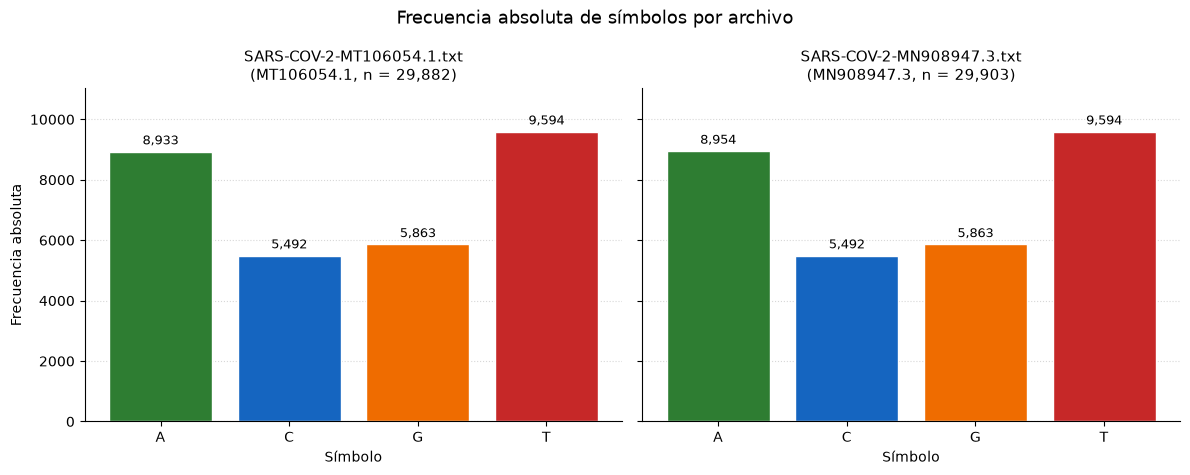

In [7]:
def simbolos_para_graficar(entradas):
    """Conjunto común de símbolos a mostrar: A, C, G, T y cualquier otro observado."""
    todos = set(ALFABETO_ESPERADO)
    for entrada in entradas:
        todos.update(entrada["resultado"]["observados"])
    return ordenar_simbolos(todos)


if ENTRADAS:
    simbolos = simbolos_para_graficar(ENTRADAS)
    colores = [COLORES.get(s, COLOR_OTROS) for s in simbolos]

    fig, ejes = plt.subplots(1, len(ENTRADAS), figsize=(6 * len(ENTRADAS), 4.8),
                             sharey=True, squeeze=False)
    ejes = ejes[0]

    for eje, entrada in zip(ejes, ENTRADAS):
        resultado = entrada["resultado"]
        alturas = [resultado["conteos"].get(s, 0) for s in simbolos]

        barras = eje.bar(simbolos, alturas, color=colores, edgecolor="white")
        eje.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9)

        eje.set_title(f"{entrada['etiqueta']}\n({entrada['accession']}, "
                      f"n = {resultado['longitud']:,})", fontsize=11)
        eje.set_xlabel("Símbolo")
        eje.grid(axis="y", linestyle=":", alpha=0.5)
        eje.set_axisbelow(True)
        eje.spines[["top", "right"]].set_visible(False)

    ejes[0].set_ylabel("Frecuencia absoluta")
    ejes[0].set_ylim(0, max(max(e["resultado"]["conteos"].get(s, 0) for s in simbolos)
                            for e in ENTRADAS) * 1.15)

    fig.suptitle("Frecuencia absoluta de símbolos por archivo", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("No hay secuencias cargadas: no se genera ninguna gráfica.")

---
## G. Análisis del algoritmo

Sea **n** la longitud de la secuencia y **k** la cantidad de símbolos *distintos*
(aquí k ≤ 5: A, C, G, T y algún posible símbolo extra).

### Complejidad temporal

- **Conteo: O(n).** El ciclo de `contar_simbolos` da exactamente **una pasada** sobre
  la secuencia. Consultar e incrementar una entrada de un diccionario es O(1)
  promedio, así que el costo total es proporcional a n.
- Para **dos secuencias** el conteo total es **O(n₁ + n₂)**: no hay interacción entre
  ellas, simplemente se suman los dos recorridos independientes.
- La alternativa `str.count()` aplicada una vez por símbolo sería **O(k·n)**: k
  pasadas completas en lugar de una. Con k pequeño y constante sigue siendo lineal en
  la práctica, pero hace k veces más trabajo y, sobre todo, **oculta el algoritmo**.

### Complejidad espacial

Conviene distinguir dos memorias distintas:

| Memoria | Tamaño | Comentario |
|---|---|---|
| **Auxiliar del conteo** (el diccionario de frecuencias) | **O(k)** | Solo una entrada por símbolo distinto. Es **independiente de n**: contar 30 mil o 30 millones de bases usa el mismo diccionario de ~4 entradas. |
| **Almacenamiento de la secuencia** | **O(n)** | Guardar el genoma completo en memoria domina el consumo total. |

Por eso el espacio total de este notebook es **O(n + k) = O(n)**, pero ese O(n) viene
de *guardar* la secuencia, no de *contarla*. Si se procesara el archivo en streaming
(símbolo por símbolo sin retenerlo), la memoria auxiliar seguiría siendo O(k).

### Trabajo adicional de presentación

Ordenar los símbolos con `ordenar_simbolos` cuesta **O(k log k)**, y construir las
tablas y gráficas cuesta **O(k)**. Este trabajo es **para presentar los resultados**
y es completamente independiente del recorrido de conteo: como k es diminuto frente a
n, no afecta la complejidad del algoritmo, que sigue siendo **O(n) en tiempo**.

---
## Comprobaciones

### Comprobación 1 — secuencia pequeña verificable a mano

Se prueba el algoritmo con la secuencia `AACGTN`, cuyo resultado puede revisarse
manualmente: longitud 6, `A` con 2 apariciones y `C`, `G`, `T`, `N` con 1 cada una.
`N` es un símbolo **inesperado** respecto al alfabeto `{A, C, G, T}`, así que este
caso también verifica que los símbolos fuera del alfabeto se conservan y se reportan.

Esta comprobación es **independiente de los resultados reales**: usa una secuencia
inventada exclusivamente para probar el código y no aparece en ninguna tabla de
resultados.

In [8]:
# --- PRUEBA CON DATOS SINTÉTICOS (no son resultados reales) ---
SECUENCIA_PRUEBA = "AACGTN"
prueba = caracterizar(SECUENCIA_PRUEBA)

print("Secuencia de prueba:", SECUENCIA_PRUEBA)
print("Longitud           :", prueba["longitud"], "(esperado: 6)")
print("Conteos            :", {s: prueba["conteos"][s] for s in ordenar_simbolos(prueba["conteos"])})
print("Más frecuente(s)   :", prueba["mas_frecuentes"], "(esperado: ['A'])")
print("Menos frecuente(s) :", prueba["menos_frecuentes"], "(esperado: C, G, T, N empatados)")
print("Inesperados        :", prueba["inesperados"], "(esperado: {'N': 1})")

assert prueba["longitud"] == 6
assert prueba["conteos"] == {"A": 2, "C": 1, "G": 1, "T": 1, "N": 1}
assert prueba["mas_frecuentes"] == ["A"]
assert prueba["menos_frecuentes"] == ["C", "G", "T", "N"]   # todos los empates
assert prueba["inesperados"] == {"N": 1}
assert abs(sum(prueba["relativas"].values()) - 1.0) < 1e-9
print("\nOK: el algoritmo reproduce el resultado calculado a mano.")

Secuencia de prueba: AACGTN
Longitud           : 6 (esperado: 6)
Conteos            : {'A': 2, 'C': 1, 'G': 1, 'T': 1, 'N': 1}
Más frecuente(s)   : ['A'] (esperado: ['A'])
Menos frecuente(s) : ['C', 'G', 'T', 'N'] (esperado: C, G, T, N empatados)
Inesperados        : {'N': 1} (esperado: {'N': 1})

OK: el algoritmo reproduce el resultado calculado a mano.


### Comprobación 2 — sobre los resultados reales

Se verifica que:

1. La **suma de los conteos coincide con la longitud** de la secuencia.
2. Las **frecuencias relativas suman aproximadamente 1** (para secuencias no vacías).
3. **A, C, G y T aparecen en las tablas** aunque tuvieran cero observaciones.
4. Como control independiente, el conteo manual coincide con `collections.Counter`.

In [9]:
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    secuencia = entrada["secuencia"]
    longitud = resultado["longitud"]

    # 1. la suma de los conteos coincide con la longitud
    suma_conteos = sum(resultado["conteos"].values())
    assert suma_conteos == longitud, (suma_conteos, longitud)

    # 2. las frecuencias relativas suman aproximadamente 1
    suma_relativas = sum(resultado["relativas"].values())
    if longitud > 0:
        assert abs(suma_relativas - 1.0) < 1e-9, suma_relativas

    # 3. A, C, G y T aparecen en la tabla aunque su conteo sea 0
    tabla = TABLAS_DETALLADAS[entrada["etiqueta"]]
    for base in ALFABETO_ESPERADO:
        assert base in set(tabla["Símbolo"]), base

    # 4. control independiente con collections.Counter
    assert Counter(secuencia) == {s: c for s, c in resultado["conteos"].items() if c > 0}

    print(f"[OK] {entrada['etiqueta']}")
    print(f"     suma de conteos = {suma_conteos:,} = longitud ({longitud:,})")
    print(f"     suma de frecuencias relativas = {suma_relativas:.12f}")
    print(f"     A, C, G, T presentes en la tabla: sí")
    print(f"     coincide con collections.Counter: sí")

print("\nTodas las comprobaciones pasaron.")

[OK] SARS-COV-2-MT106054.1.txt
     suma de conteos = 29,882 = longitud (29,882)
     suma de frecuencias relativas = 1.000000000000
     A, C, G, T presentes en la tabla: sí
     coincide con collections.Counter: sí
[OK] SARS-COV-2-MN908947.3.txt
     suma de conteos = 29,903 = longitud (29,903)
     suma de frecuencias relativas = 1.000000000000
     A, C, G, T presentes en la tabla: sí
     coincide con collections.Counter: sí

Todas las comprobaciones pasaron.


---
## H. Interpretación y conclusión

Las observaciones siguientes se generan a partir de los resultados calculados en este
notebook.

In [10]:
print("OBSERVACIONES (generadas a partir de los datos)")
print("=" * 78)
for entrada in ENTRADAS:
    resultado = entrada["resultado"]
    relativas = resultado["relativas"]

    print(f"\n{entrada['etiqueta']}  ({entrada['accession']})")
    print(f"  Longitud total: {resultado['longitud']:,} símbolos.")
    print(f"  Alfabeto observado: "
          f"{{{', '.join(ordenar_simbolos(resultado['observados']))}}} "
          f"({len(resultado['observados'])} símbolos distintos).")
    print(f"  Más frecuente(s): {', '.join(resultado['mas_frecuentes'])} "
          f"({max(relativas[s] for s in resultado['mas_frecuentes']) * 100:.2f} %).")
    print(f"  Menos frecuente(s): {', '.join(resultado['menos_frecuentes'])} "
          f"({min(relativas[s] for s in resultado['menos_frecuentes']) * 100:.2f} %).")
    if resultado["inesperados"]:
        print(f"  Símbolos fuera de A/C/G/T: {resultado['inesperados']} "
              f"(total {resultado['total_inesperados']}). Se conservaron sin modificar.")
    else:
        print("  Símbolos fuera de A/C/G/T: ninguno.")
    suma_acgt = sum(relativas[b] for b in ALFABETO_ESPERADO) * 100
    print(f"  A + C + G + T = {suma_acgt:.2f} % de la longitud total.")

if len(ENTRADAS) == 2:
    a, b = ENTRADAS
    print("\n" + "=" * 78)
    print("COMPARACIÓN DE COMPOSICIÓN (no es una comparación posición a posición)")
    diferencia = a["resultado"]["longitud"] - b["resultado"]["longitud"]
    print(f"  Diferencia de longitud: {abs(diferencia):,} símbolos "
          f"({'la primera es más larga' if diferencia > 0 else 'la segunda es más larga' if diferencia < 0 else 'iguales'}).")
    for base in ALFABETO_ESPERADO:
        pa = a["resultado"]["relativas"][base] * 100
        pb = b["resultado"]["relativas"][base] * 100
        print(f"  {base}: {pa:6.2f} %  vs  {pb:6.2f} %   (diferencia {abs(pa - pb):.2f} puntos)")

OBSERVACIONES (generadas a partir de los datos)

SARS-COV-2-MT106054.1.txt  (MT106054.1)
  Longitud total: 29,882 símbolos.
  Alfabeto observado: {A, C, G, T} (4 símbolos distintos).
  Más frecuente(s): T (32.11 %).
  Menos frecuente(s): C (18.38 %).
  Símbolos fuera de A/C/G/T: ninguno.
  A + C + G + T = 100.00 % de la longitud total.

SARS-COV-2-MN908947.3.txt  (MN908947.3)
  Longitud total: 29,903 símbolos.
  Alfabeto observado: {A, C, G, T} (4 símbolos distintos).
  Más frecuente(s): T (32.08 %).
  Menos frecuente(s): C (18.37 %).
  Símbolos fuera de A/C/G/T: ninguno.
  A + C + G + T = 100.00 % de la longitud total.

COMPARACIÓN DE COMPOSICIÓN (no es una comparación posición a posición)
  Diferencia de longitud: 21 símbolos (la segunda es más larga).
  A:  29.89 %  vs   29.94 %   (diferencia 0.05 puntos)
  C:  18.38 %  vs   18.37 %   (diferencia 0.01 puntos)
  G:  19.62 %  vs   19.61 %   (diferencia 0.01 puntos)
  T:  32.11 %  vs   32.08 %   (diferencia 0.02 puntos)


### Observaciones

- **Formato.** Aunque ambos archivos tienen extensión `.txt`, en realidad son
  archivos **FASTA** con un único registro cada uno: una línea de encabezado que
  empieza con `>` y la secuencia repartida en líneas de 70 caracteres, con
  terminadores de línea CRLF. Por eso fue necesario inspeccionarlos antes de leerlos:
  leerlos como "texto plano" sin tratar el encabezado habría metido las letras de la
  descripción dentro del conteo.

- **Longitudes.** Las dos secuencias tienen longitudes del mismo orden pero **no
  idénticas**, con una diferencia de unas pocas decenas de símbolos sobre casi 30 000.

- **Composición.** En ambas secuencias las bases más abundantes son **T** y **A**, y
  las menos abundantes **C** y **G**; los cuatro porcentajes son muy parecidos entre
  los dos archivos. Es decir, las dos secuencias tienen una **composición de bases
  prácticamente indistinguible** a este nivel de análisis.

- **Caracteres inesperados.** No se encontró **ningún** símbolo fuera de
  `{A, C, G, T}` en ninguno de los dos archivos. Por eso A + C + G + T suma 100 % en
  ambos casos y no hubo nada que "manejar". Si hubieran aparecido códigos de
  ambigüedad como **`N`**, eso **no significaría que el archivo esté corrupto**: en
  secuenciación, `N` (y otros códigos IUPAC) indica una posición donde la base no
  pudo determinarse con certeza, y es parte normal de muchos genomas publicados. Por
  eso el lector los conserva y los reporta por separado en lugar de borrarlos.

### Límites de este análisis

Este es el punto más importante a tener claro antes de pasar a las siguientes partes:

- Contar frecuencias **descarta por completo el orden** de los símbolos. Dos
  secuencias con exactamente la misma composición pueden ser completamente distintas.
- Por lo tanto, **comparar frecuencias no permite identificar en qué posiciones hay
  mutaciones**, ni cuáles son, ni cuántas.
- Y **tampoco permite demostrar que dos secuencias sean idénticas**: que dos
  histogramas coincidan es una condición *necesaria* para la igualdad, no
  *suficiente*.

Responder esas preguntas requiere algoritmos que **sí usen el orden** —alineamiento
de secuencias, búsqueda de patrones, subcadenas comunes— que son el tema de las
partes siguientes de la situación problema. Aquí lo único que se ha establecido es
que ambos archivos se leyeron correctamente, que su alfabeto es exactamente el
esperado y cuál es su composición global.

### Conclusión

La Parte 1 queda cubierta: se implementó un lector que separa formato de secuencia
sin alterar los símbolos, y un algoritmo de conteo explícito de **una sola pasada,
O(n) en tiempo y O(k) en memoria auxiliar**, verificado contra un caso calculado a
mano y contra un conteo independiente. Ambos genomas resultaron estar limpios: solo
A, C, G y T, sin ningún carácter inesperado.